# Multiple Linear Regression - CO2 Emission Prediction

## 1. Import Libraries

In this section we import the required Python libraries for data manipulation, visualization, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## 2. Loading the Dataset

The dataset contains vehicle information. We load it into a pandas DataFrame so we can explore and prepare the data.

In [2]:
df = pd.read_csv(r"../data/FuelConsumption.csv")

## 3. Initial Data Inspection

`head()` displays the first rows of the dataset to understand the structure and feature names.

In [3]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


`tail()` shows the last rows of the dataset and helps confirm that the data was loaded correctly.

In [4]:
df.tail()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260
1066,2014,VOLVO,XC90 AWD,SUV - STANDARD,3.2,6,AS6,X,14.9,10.2,12.8,22,294


## Dataset Dimensions

`shape` returns the number of samples (rows) and features (columns).

In [5]:
df.shape

(1067, 13)

## Data Types and Missing Values

`info()` helps identify column types, non-null values, and possible data quality issues.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   str    
 2   MODEL                     1067 non-null   str    
 3   VEHICLECLASS              1067 non-null   str    
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   str    
 7   FUELTYPE                  1067 non-null   str    
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 142.1 KB


`describe()` provides statistical summaries such as mean, minimum, maximum, and standard deviation.

In [7]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


`columns` lists all available features in the dataset.

In [8]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='str')

## Missing Value Check

Missing values must be handled before training a machine learning model.

In [9]:
df.isnull().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

## Correlation Analysis

Correlation helps us understand relationships between numerical features and the target variable.

In [10]:
df.corr(numeric_only=True)

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


## Feature Selection

Based on domain knowledge and correlation analysis, we select meaningful features for predicting CO2 emissions.

In [11]:
features = ["ENGINESIZE" , "CYLINDERS" , "FUELCONSUMPTION_COMB"]
df[features].corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB
ENGINESIZE,1.000000,0.934011,0.819482
CYLINDERS,0.934011,1.000000,0.776788
FUELCONSUMPTION_COMB,0.819482,0.776788,1.000000


## Creating X and y

X contains input features and y contains the target variable that we want to predict.

In [12]:
X = df[['ENGINESIZE','CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS']

Checking the shape confirms the number of samples and selected features.

In [13]:
print(X.shape)
print(y.shape)

(1067, 3)
(1067,)


## Train-Test Split

We separate training data from testing data to evaluate how well the model performs on unseen examples.

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(853, 3)
(853,)
(214, 3)
(214,)


## Model Training

The Linear Regression model learns the relationship between multiple input features and CO2 emissions.

In [15]:
model = LinearRegression()
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[11.21, 7.16, 9.52]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,67.35
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


The coefficients represent the effect of each feature in the regression equation.

In [16]:
model.coef_

array([11.2094395 ,  7.15561381,  9.5208118 ])

The intercept is the baseline value of the regression equation.

In [17]:
model.intercept_

np.float64(67.34838518362096)

## Prediction

The trained model predicts CO2 emissions for the test dataset.

In [18]:
y_pred = model.predict(X_test)

Comparing actual and predicted values helps visually inspect model performance.

In [19]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison.head()

,Actual,Predicted
732,304,302.952377
657,221,240.914900
168,294,272.502441
86,221,235.310180
411,207,204.077026


## Evaluation Metrics

MAE measures the average prediction error.

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 16.721593983516485
MSE: 512.8551370148302
R2: 0.8759705206914069


## Model Comparison

We create simpler models to evaluate the contribution of additional features.

In [21]:
X1 = df[["ENGINESIZE"]]
y = df["CO2EMISSIONS"]

In [22]:
X1_train , X1_test , y1_train , y1_test = train_test_split(X1 , y , test_size=0.2 , random_state=42)

In [23]:
model1 = LinearRegression()
model1.fit(X1_train , y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[38.99]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['ENGINESIZE']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,126.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [24]:
y1_pred = model1.predict(X1_test)

In [25]:
r2_model1 = r2_score(y1_test , y1_pred)
print("Model 1 R2:", r2_model1)

Model 1 R2: 0.7615595731934373


## Model 2: Engine Size + Cylinders

Adding features allows us to measure their contribution to prediction quality.

In [26]:
X2 = df[["ENGINESIZE" , "CYLINDERS"]]
y = df["CO2EMISSIONS"]

In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split( X2, y, test_size=0.2, random_state=42 )

In [28]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[28.94, 8.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['ENGINESIZE','CYLINDERS']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,111.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [29]:
y2_pred = model2.predict(X2_test)

In [30]:
r2_model2 = r2_score(y2_test, y2_pred)

print("Model 2 R2:", r2_model2)

Model 2 R2: 0.7748904347438592


## Final Model Feature Importance

The final model uses three features. We inspect coefficients to understand the learned relationship.

In [31]:
X3 = df[
[
'ENGINESIZE',
'CYLINDERS',
'FUELCONSUMPTION_COMB'
]
]

Creating a table makes model coefficients easier to interpret.

In [32]:
coefficients = pd.DataFrame({
    "Feature": X3.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,ENGINESIZE,11.209439
1,CYLINDERS,7.155614
2,FUELCONSUMPTION_COMB,9.520812


## Actual vs Predicted Visualization

A good regression model produces predictions close to the actual values.

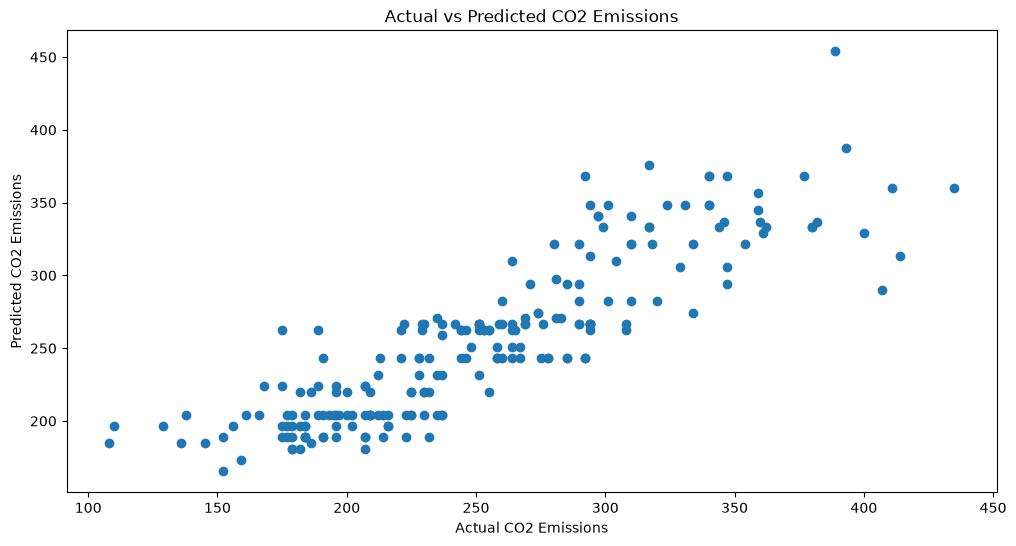

In [ ]:
plt.figure(figsize=(12,6))
plt.scatter(y1_test , y1_pred)
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")
plt.title("Actual vs Predicted CO2 Emissions")
plt.show()

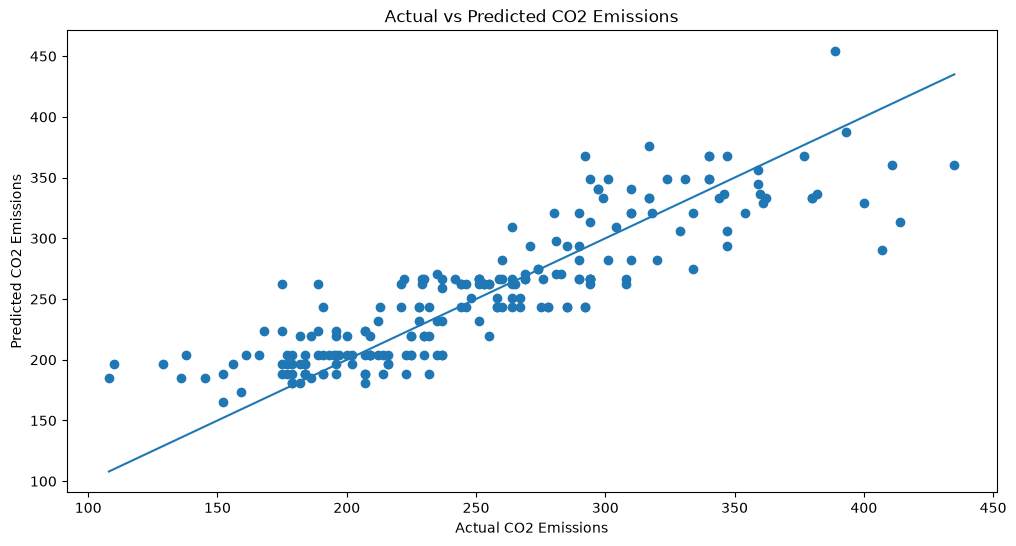

In [35]:
plt.figure(figsize=(12,6))
plt.scatter(y1_test , y1_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")

plt.title("Actual vs Predicted CO2 Emissions")

plt.show()

## Residual Analysis

Residuals represent the difference between actual and predicted values.

In [37]:
residuals = y_test - y_pred
residuals.head()

732     1.047623
657   -19.914900
168    21.497559
86    -14.310180
411     2.922974
Name: CO2EMISSIONS, dtype: float64

The residual plot helps identify systematic prediction errors.

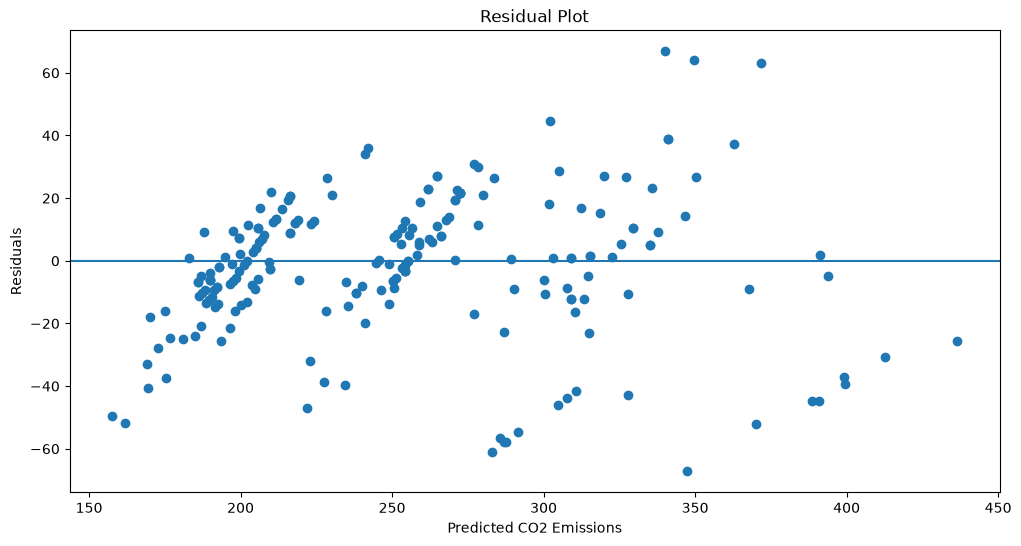

In [38]:
plt.figure(figsize=(12,6))
plt.scatter(y_pred , residuals)

plt.xlabel("Predicted CO2 Emissions")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.axhline(y=0)

plt.show()